### classifier, torch

In [1]:
%pip install --quiet torch datasets nltk tqdm matplotlib kagglehub ipywidgets numpy pandas

import numpy as np
import torch
from datasets import load_dataset
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: /Users/ant.korneev/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [3]:
with open(path + '/IMDB Dataset.csv', "r") as file:
    content = file.read()

In [4]:
df = pd.read_csv(path + '/IMDB Dataset.csv', sep=',', header=None)
ds = df.to_numpy()
ds = ds[1:]

len(ds)

50000

In [5]:
import nltk

tokenizer = nltk.tokenize.WordPunctTokenizer()

train = [tokenizer.tokenize(pair[0].lower()) for pair in ds[:25000]]
val = [tokenizer.tokenize(pair[0].lower()) for pair in ds[25000:]]

In [ ]:
# [negative prob, positive prob]
# TODO: just 0 for neg, 1 for pos
train_labels = [[1, 0] if pair[1] == 'negative' else [0, 1] for pair in ds[:25000]]
val_labels = [[1, 0] if pair[1] == 'negative' else [0, 1] for pair in ds[25000:]]

In [7]:
PAD_TOKEN = '<pad>'

train_seq_len = 0
for t in train:
    if len(t) > train_seq_len:
        train_seq_len = len(t)

train = [text + [PAD_TOKEN] * (train_seq_len - len(text)) for text in train]

val_seq_len = 0
for t in val:
    if len(t) > val_seq_len:
        val_seq_len = len(t)

val = [text + [PAD_TOKEN] * (val_seq_len - len(text)) for text in val]

In [8]:
vocab_set = set()
for t in train:
    for w in t:
        vocab_set.add(w)
        
for t in val:
    for w in t:
        vocab_set.add(w)

In [9]:
vocab_i_map = {}
i_vocab_map = {}
for i, token in enumerate(vocab_set):
    vocab_i_map[token] = i
    i_vocab_map[i] = token

In [10]:
for i, text in enumerate(train):
    for j, token in enumerate(text):
        train[i][j] = vocab_i_map[token]
        
for i, text in enumerate(val):
    for j, token in enumerate(text):
        val[i][j] = vocab_i_map[token]

In [11]:
print(val[1])
[i_vocab_map[i] for i in val[1]]

[34402, 46850, 62272, 69583, 25656, 76352, 40530, 18143, 15080, 102054, 46470, 104288, 63456, 1773, 68365, 3124, 78467, 66362, 76352, 45654, 13, 69641, 69194, 1773, 39375, 95377, 68365, 46850, 35734, 62272, 68432, 35734, 98589, 62272, 27877, 50385, 35734, 74344, 69641, 36870, 46850, 62272, 34577, 30998, 99466, 43450, 1773, 79587, 66108, 54931, 57100, 54931, 81585, 84522, 20623, 62272, 9649, 42020, 27960, 46850, 72496, 18696, 46850, 2919, 49979, 57680, 46693, 10630, 52004, 95377, 78902, 39075, 85644, 69641, 15234, 35734, 1773, 45606, 473, 13889, 51840, 69641, 78902, 55684, 95377, 71150, 68897, 57680, 58979, 104146, 2919, 3124, 78902, 26723, 103776, 95377, 13889, 71969, 33870, 50701, 104032, 473, 51210, 46850, 76116, 13889, 68476, 37741, 46850, 69641, 13889, 13777, 71552, 37741, 46850, 81948, 55451, 99006, 32432, 42020, 84522, 18031, 24266, 80128, 13889, 71111, 14111, 93351, 59665, 66852, 47812, 42020, 78902, 53432, 473, 76352, 24107, 46850, 35734, 62272, 93543, 20623, 54647, 62272, 5798

['god',
 ',',
 'i',
 'never',
 'felt',
 'so',
 'insulted',
 'in',
 'my',
 'whole',
 'life',
 'than',
 'with',
 'this',
 'crap',
 '.',
 'there',
 'are',
 'so',
 'many',
 'ways',
 'to',
 'describe',
 'this',
 'piece',
 'of',
 'crap',
 ',',
 'that',
 'i',
 'think',
 'that',
 'if',
 'i',
 'said',
 'everything',
 'that',
 'came',
 'to',
 'mind',
 ',',
 'i',
 'would',
 'get',
 'banned',
 'by',
 'this',
 'site',
 '.<',
 'br',
 '/><',
 'br',
 '/>',
 'how',
 'do',
 'i',
 'begin',
 '?',
 'well',
 ',',
 'for',
 'one',
 ',',
 'it',
 'doesn',
 "'",
 't',
 'take',
 'knowledge',
 'of',
 'the',
 'original',
 'series',
 'to',
 'know',
 'that',
 'this',
 'movie',
 'is',
 'a',
 'slap',
 'to',
 'the',
 'face',
 'of',
 'people',
 'who',
 "'",
 've',
 'seen',
 'it',
 '.',
 'the',
 'biggest',
 'butchering',
 'of',
 'a',
 'theme',
 'song',
 'ever',
 'made',
 'is',
 'here',
 ',',
 'from',
 'a',
 'metal',
 'version',
 ',',
 'to',
 'a',
 'freaking',
 'rap',
 'version',
 ',',
 'what',
 'were',
 'they',
 'thinking

In [13]:
vocab_size = len(vocab_set)
emb_dim = 64
hid_size = 512

In [ ]:
class Cls(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.embs = torch.nn.Embedding(vocab_size, emb_dim)
        
        self.lstm = torch.nn.LSTM(emb_dim, hid_size, 4)
        
        self.norm = torch.nn.LayerNorm(hid_size)
        self.dropout = torch.nn.Dropout(p=0.2)
        
        self.fc1 = torch.nn.Linear(hid_size, hid_size)
        self.activation1 = torch.nn.ReLU()
        
        self.fc2 = torch.nn.Linear(hid_size, 2)
        
    # X: [batch_size, seq_len]
    def forward(self, X):
        X = self.embs(X) # [batch_size, seq_len, emb_dim]
        
        X, (hn, cn) = self.lstm(X)
        
        X = self.norm(X)
        X = self.dropout(X)
        
        X = self.fc1(X) # [batch_size, seq_len, hid_size]
        X = self.activation1(X)
        
        X = X.max(dim=-2).values # [batch_size, hid_size]
        
        X = self.fc2(X) # [batch_size, seq_len, 2]
    
        return X

In [88]:
foo = torch.randn([2, 10, 5])
foo, foo.max(dim=-2).values.type()

(tensor([[[-9.8538e-01, -3.3503e-01,  9.3122e-01, -1.2495e+00, -2.0305e+00],
          [-1.7077e+00, -1.2694e+00,  6.9037e-01,  2.4156e-02, -1.1834e-01],
          [ 8.2417e-01,  9.3111e-01,  3.8481e-01, -4.1955e-02, -7.8932e-03],
          [-1.7944e+00,  6.8948e-01,  2.7938e+00, -1.8599e-01,  2.7621e-01],
          [ 5.0995e-01,  2.7251e-01, -6.7184e-01,  1.4444e+00, -5.2515e-01],
          [-9.0682e-01,  5.8921e-01,  1.3211e+00, -5.2879e-01, -1.3563e+00],
          [ 1.1215e+00,  6.8911e-01, -9.9595e-02, -7.5568e-01, -1.3823e+00],
          [-5.2919e-01,  5.6354e-01,  1.2657e-01,  2.3409e+00, -3.1804e-01],
          [ 4.0469e-01,  3.3120e-01,  5.6204e-01, -8.3499e-01, -3.5265e-01],
          [-8.8871e-01,  2.4102e-01,  3.8221e-01, -7.7857e-01,  2.3011e+00]],
 
         [[-1.1939e+00,  6.6762e-01,  2.9109e-01,  7.4136e-01, -3.3036e-01],
          [-2.5494e+00,  4.3584e-01, -6.9052e-01, -1.5163e+00,  1.3926e+00],
          [-4.2351e-01,  1.8574e-01, -1.4025e+00,  5.7060e-01, -9.6164e-0

In [77]:
dummy_batch = torch.tensor(train[:2])

In [78]:
model = Cls()

In [79]:
model.forward(dummy_batch)

tensor([[-0.0682, -0.1288],
        [-0.1043, -0.1202]], grad_fn=<AddmmBackward0>)

In [80]:
opt = torch.optim.Adam(model.parameters())

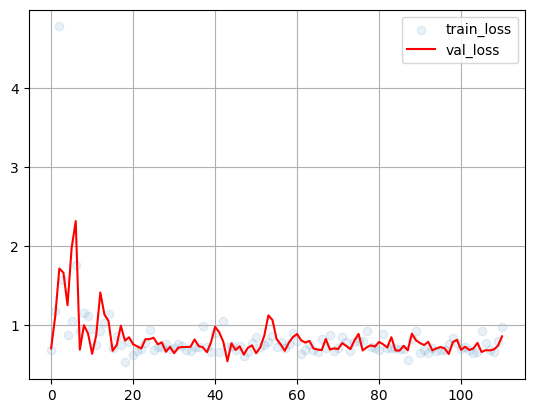

  7%|▋         | 112/1562 [06:02<1:18:06,  3.23s/it]


KeyboardInterrupt: 

In [97]:
batch_size = 16

train_loss = []
val_loss = []

for i in tqdm(range(0, len(train), batch_size), total=len(train) // batch_size):
    if i + batch_size > len(train):
        break
    
    batch = train[i : i + batch_size]
    batch = torch.tensor(batch)
    val_batch = val[i : i + batch_size]
    val_batch = torch.tensor(val_batch)
    
    batch_labels = train_labels[i : i + batch_size]
    batch_labels = torch.tensor(batch_labels).to(torch.float32)
    val_batch_labels = val_labels[i : i + batch_size]
    val_batch_labels = torch.tensor(val_batch_labels).to(torch.float32)
    
    logits = model.forward(batch)
    val_logits = model.forward(val_batch)
    
    batch_train_loss = torch.nn.functional.cross_entropy(logits, batch_labels)
    train_loss.append(batch_train_loss.detach().numpy())
    batch_val_loss = torch.nn.functional.cross_entropy(val_logits, val_batch_labels)
    val_loss.append(batch_val_loss.detach().numpy())
    
    batch_train_loss.backward()
    opt.step()
    opt.zero_grad()
    
    if i % 10 == 0:
        clear_output(True)
        plt.scatter(range(len(train_loss)), train_loss, alpha=0.1, label='train_loss')
        if len(val_loss):
            plt.plot(range(len(val_loss)), val_loss, color='red', label='val_loss')
        plt.legend(); plt.grid(); plt.show()
    

In [98]:
bad = ['awful! a waste of time!', 'this movie is so bad it is of its own kind', 'complete utter garbage!']
good = ['what a nice movie!', 'what a day to have eyes! absolutely astonishing!', 'solid 10! I am speechless']

In [99]:
all = bad + good

for i, review in enumerate(all):
    tokenized = tokenizer.tokenize(review.lower())
    all[i] = [vocab_i_map[token] for token in tokenized]
    

In [104]:
for review in all:
    logits = model.forward(torch.tensor(review))
    print(torch.nn.functional.softmax(logits, dim=-1).tolist())

[0.6935058236122131, 0.30649423599243164]
[0.6985847353935242, 0.301415354013443]
[0.6424306035041809, 0.3575693666934967]
[0.6871768236160278, 0.3128231465816498]
[0.7091007232666016, 0.29089927673339844]
[0.659122109413147, 0.3408779203891754]


In [ ]:
# TODO: проверить на примерах из трейна

In [110]:
foo = [3, 1, 2]
bar = ['q', 'w', 'e']
foo.sort()
list(zip(foo, bar))

[(1, 'q'), (2, 'w'), (3, 'e')]

In [112]:
f'qw{foo}e'

'qw[1, 2, 3]e'

In [116]:
baz = set([1])
baz.update({2})
baz

{1, 2}

In [119]:
'hello'[::-1]

'olleh'

In [125]:
spam = 'SpamSpamBaconSpamEggsSpamSpam'
spam.strip('ampS')

'BaconSpamEggs'

In [128]:
f'{1.234:.2f}'

'1.23'

In [ ]:
import re

r = re.compile(r'\d+')

[r.search(i).group() if r.search(i) != None else None for i in ['1we', 'w1e', 'qwe123qwe123123']]

r.findall('qwe123qwe123123')

['123', '123123']